# Chapter 5 — Adaptive Stochastic Shortest Paths

### Implementation with Post-Decision State and ADP
The core idea is: upon reaching a node, the agent knows the costs of the available arcs at that state and decides where to go.

### Model Structure

$$
S_t = (N_t, I_t)
$$

| Symbol | Meaning |
| :--- | :--- |
| $N_t$ | Current node |
| $I_t$ | Information: observed costs of the arcs leaving $N_t$ |
| $x_t$ | Decision: next chosen node |
| $W_{t+1}$ | New exogenous information observed after the decision |
| $C(S_t, x_t)$ | Realized cost of the decision (contribution) |
| $S_{t+1}$ | Next state reached |

---

**The decision cycle follows:**

> **Policy** $\rightarrow$ **Exogenous Information** $\rightarrow$ **Contribution** $\rightarrow$ **Transition**

In [1]:
import random # Usamos random para gerar os custos observados dos arcos
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### 2. Problem Network

The network is stored in a dictionary.

$$ \texttt{network}[i] = \{ (j, \bar{c}_{ij}) : j \in N_i^+ \} $$

| Variable | Interpretation |
|---|---|
| $(i)$ | current node |
| $(j)$ | neighboring node |
| $(N_i^+)$ | set of neighbors accessible from $(i)$ |
| $(\bar c_{ij})$ | average cost of the arc $((i,j)$) |

In this extension, the network values are used as **average costs**, not as realized costs.

In [2]:
## Rede
network = {
    1:[(2,12.6),(3,8.4),(4,9.2)],
    2:[(1,12.6),(3,8.1),(5,17.4)],
    3:[(1,8.4),(2,8.1),(4,3.6),(6,15.9)],
    4:[(1,9.2),(3,3.6),(7,16.5)],
    5:[(2,17.4),(6,12.7),(8,15.9)],
    6:[(3,15.9),(5,12.7),(7,13.5),(9,8.9)],
    7:[(4,16.5),(6,13.5),(10,20.2)],
    8:[(5,15.9),(9,9.6),(11,5.7)],
    9:[(8,9.6),(10,4.5),(11,7.3)],
    10:[(7,20.2),(9,4.5),(11,2.3)],
    11:[(8,5.7),(9,7.3),(10,2.3)]
}

We define:

$$
\begin{aligned}
q &= 1 \\
r &= 11
\end{aligned}
$$

| Variable in code | Meaning |
|---|---|
| `origin_node` | origin node \(q\) |
| `destination_node` | destination node \(r\) |

In [3]:
# 2. Parâmetros iniciais
origin_node = 1 # Current Node / State "r"
destination_node = 11 # Destination Node / State "q"

### 4. Initial guess for $V_{\text{post}}$

Before adaptive learning, we calculate a deterministic solution using Bellman:

$$
v_i = \min_{j \in N_i^+} \left( \bar{c}_{ij} + v_j \right), \qquad v_{11} = 0
$$

These values will be used only as an **initial guess** for:

$$
V_{\text{post}}(j)
$$

| Variable | Meaning |
|---|---|
| `value_function[i]` | minimum deterministic cost starting from node \(i\) |
| `V_post[j]` | learned approximation of the post-decision value associated with node \(j\) |

In [4]:
# 4. Treinamento do V_bar_post
# It calculates an initial estimate of the future cost from each node to the destination. - "Database"
def initialize_v_bar_post(network, destination_node):
    value_function = {
        node: float("inf") # Initial value function for all nodes is set to infinity
        for node in network # ideia: we dont know how much it costs to get to the destination 
    }

    value_function[destination_node] = 0 # The cost to reach the destination from itself is zero

    for _ in range(len(network)): # We repeat the update several times. 
                                  # This allows the destination information to propagate through the network.
        for node in network:      # We explored all the nodes of the network.
            if node == destination_node: # We skip the destination node since we already know its value function is zero.
                continue

            best_cost = float("inf") # We begin by assuming that the best cost is infinite.


            for neighbor, C_t in network[node]: # For each neighbor of the current node,
                # we calculate the candidate cost to reach the destination through that neighbor.
                # Bellman's equation
                candidate_cost = C_t + value_function[neighbor] # Candidate cost = immediate cost + future cost

                if candidate_cost < best_cost: # If we find a better route,
                    best_cost = candidate_cost # # We've updated the lowest known cost.

            value_function[node] = best_cost # After iterating through all neighbors, 
            # we update the value function for the current node with the best cost found.

    return value_function

### 5. Exogenous Information

The function below generates the observed costs of the arcs leaving a node.

For each arc $(i,j)$, we sample:

$$
\hat{c}_{tij} \in [0.8\bar{c}_{ij}, \, 1.2\bar{c}_{ij}]
$$

| Variable | Meaning |
|---|---|
| `node` | node where the costs will be observed |
| `average_cost` | average cost $(\bar c_{ij})$ |
| `observed_cost` | observed cost $(\hat c_{tij}$) |
| `observed_costs[j]` | observed cost of the arc to neighbor $(j)$ |

In [5]:
# 5. Exogenous information (Wt+1 = It+1)
def exogenous_information(network, S_t):
    observed_costs = {} # Dictionary: neighbor -> observed cost to reach him

    # For each neighbor of the current node, we generate an observed cost 
    # by adding some random noise to the average cost.
    for neighbor, average_cost in network[S_t]:
        observed_cost = random.uniform(
            0.8 * average_cost, # We generate a random cost between 80% 
            1.2 * average_cost  # and 120% of the average cost.
        )

        # We store the observed cost for each neighbor in the dictionary.
        observed_costs[neighbor] = observed_cost

    return observed_costs

### 6. Initial State $(S_0)$

The adaptive state is:

$
S_t=(N_t,I_t)
$

At the beginning:

$
S_0=(N_0,I_0)
$

with $(N_0=q)$.

| State Component | Meaning |
|---|---|
| $S_t$ `["node"]` | current node $(N_t)$ |
| $S_t$ `["observed_costs"]` | information $(I_t)$: available observed costs |

In [6]:
# 6. Inicial State
def initial_state(network, origin_node):
    N_t = origin_node
    # See the exogenous information function to understand what is I_t
    I_t = exogenous_information(network, N_t)

    # The complete state is S_t = (N_t, I_t)
    S_t = {
        "node": N_t,
        "observed_costs": I_t
    }

    return S_t

### 7. Policy $x_t = X^\pi(S_t)$

The policy chooses the next node by minimizing:

$$
x_t = \mathop{\arg\min}_{j \in N_{N_t}^+} \left( \hat{c}_{t, N_t, j} + V_{\text{post}}(j) \right)
$$

| Variable | Meaning |
|---|---|
| `observed_cost` | observed immediate cost |
| `V_post[neighbor]` | approximate future cost |
| `candidate_cost` | sum of the two terms |
| `best_neighbor` | decision $(x_t)$ |

In [7]:
# 7. Policy : Implements the decision rule x_t = X^pi(S_t)
def policy(S_t, V_post):
    # We extract from the state S_t the costs paid 
    # for the arcs available from the current node.
    observed_costs = S_t["observed_costs"]

    
    best_cost = float("inf") # We inicialize the best cost as infinity 
    best_neighbor = None # and the best neighbor as None.

    # We avalibe each possible neighbor at actual node
    for neighbor, observed_cost in observed_costs.items():
        # We calculate the candidate cost to reach the destination through that neighbor.
        candidate_cost = observed_cost + V_post[neighbor]

        if candidate_cost < best_cost: # If we find a better route,
            best_cost = candidate_cost # We've updated the lowest known cost.
            best_neighbor = neighbor # and we update the best neighbor to move to.

    return best_neighbor

### 8. Contribution $C(S_t, x_t)$

The contribution is the cost actually paid for the chosen arc:

$$
C(S_t, x_t) = \hat{c}_{t, N_t, x_t}
$$

In the code, simply retrieve the observed cost associated with the chosen node.

In [8]:
# 8. Contribution Function: cost of moving from current node to next node
def contribution(S_t, x_t):
    observed_costs = S_t["observed_costs"]
    return observed_costs[x_t]

### 9. State Transition

After the decision $x_t$ and the arrival of $W_{t+1}$, we construct:

$$
S_{t+1} = S^M(S_t, x_t, W_{t+1})
$$

In this problem:

$$
S_{t+1} = (x_t, W_{t+1})
$$

| Variable | Meaning |
| :--- | :--- |
| $x_t$ | New node reached |
| $W_{t+1}$ | Observed costs available at the new node |
| $S_{t+1}$ | Updated state |

In [9]:
# 9 Transition function: how the state evolves after taking an action and observing new costs
def transition(S_t, x_t, W_t_plus_1):
    S_t_plus_1 = {
        "node": x_t, # Decision made: next node chosen.
        "observed_costs": W_t_plus_1  # New observed costs after moving to the next node.
    }

    return S_t_plus_1 # Next state is the new node and the new observed costs.

### 10. Stepsize — Equation (5.18)

The weight given to the new observation is:

$$
\alpha_n = \frac{\theta^\alpha}{\theta^\alpha + n - 1}
$$

| Variable | Meaning |
| :--- | :--- |
| $\theta^\alpha$ | Smoothing parameter |
| $n$ | Episode index (iteration) |
| $\alpha_n$ | Weight of the new information (learning rate) |

In [10]:
# 10. Stepsize function - equation (5.18)
def stepsize(theta_alpha, n):
    return theta_alpha / (theta_alpha + n - 1)

### 11. Sample Value — Equation (5.16)

The sample estimate used in learning is:

$$
\hat{v}_t^{x,n}(i) = \min_{j \in N_i^+} \left( \hat{c}_{tij}^{\,n} + V_t^{x,n-1}(j) \right)
$$

| Variable | Meaning |
| :--- | :--- |
| `sampled_value(...)` | Function that calculates $\hat{v}_t^{x,n}(i)$ |
| `best_cost` | Lowest candidate cost found (the value of the $\min$) |

In [11]:
# 11. Sampled Value Function: equation (5.16)
# Given the current situation, what is the lowest estimated cost among all possible decisions?

def sampled_value(S_t, V_post):
    # We extracted the observed costs of the available arches from the state.
    observed_costs = S_t["observed_costs"]

    best_cost = float("inf") # We initialize the best cost as infinite.

    # We evaluated every possible neighbor.
    for neighbor, observed_cost in observed_costs.items():
        # For each possible decision, we calculate:
        # observed immediate cost + approximate future value.
        candidate_cost = observed_cost + V_post[neighbor]

        # We kept the lowest value found.
        if candidate_cost < best_cost:
            best_cost = candidate_cost

    return best_cost

### 12. Updating $V_{\text{post}}$ — Equation (5.17)

We update the post-decision approximation by:

$$
V_{t-1}^{x,n}(i) = (1 - \alpha_n) V_{t-1}^{x,n-1}(i) + \alpha_n \hat{v}_t^{x,n}(i)
$$

| Variable | Meaning |
| :--- | :--- |
| `node_to_update` | Node $i$ whose value will be updated |
| `v_hat` | Calculated sample value ($\hat{v}_t^{x,n}$) |
| `alpha_n` | Stepsize ($\alpha_n$) |
| `V_post[...]` | New post-decision value approximation |

In [12]:
# 12. Update Function for Post-Decision Value: equation (5.17)
# Update the post-decision value approximation

def update_V_post(V_post, node_to_update, v_hat, alpha_n):
    V_post[node_to_update] = (
        (1 - alpha_n) * V_post[node_to_update] # Keep a portion of the old value
        + alpha_n * v_hat # and add a fraction of the new estimate
    )

    return V_post

### 13. A Simulation and Learning Episode

This block executes a complete trajectory until the destination is reached.

The internal order follows the decision cycle:

$$
\boxed{
\text{Policy} \rightarrow \text{Exogenous Information} \rightarrow \text{Contribution} \rightarrow \text{Transition}
}
$$

After each transition, the algorithm applies the **ADP** (Approximate Dynamic Programming) update to refine the post-decision value function.

| Variable | Meaning |
| :--- | :--- |
| $S_t$ | Current state (node and available information) |
| $x_t$ | Decision made by the policy (next node) |
| $W_{t+1}$ | New exogenous information (observed costs at the new node) |
| $C_t$ | Realized cost on arc $(S_t, x_t)$ |
| $S_{t+1}$ | Next state reached |
| `path` | List containing the path traversed in the episode |
| `total_cost` | Accumulated sum of costs $C_t$ in the episode |

In [13]:
# 13. Main Loop
# Política → Informação exógena → Contribuição → Transição

def run_episode(
    network,
    origin_node,
    destination_node,
    V_post,
    theta_alpha,
    n
):
    total_cost = 0
    path = []

    alpha_n = stepsize(theta_alpha, n)

    # Estado inicial S_0 = (N_0, I_0)
    S_t = initial_state(network, origin_node)

    while S_t["node"] != destination_node:
        path.append(S_t["node"])

        # 1. Police (x_t = X^pi(S_t))  =====================================
        x_t = policy(S_t, V_post)

        # 2. Exogenous Information (W_{t+1}) ===============================
        # observed costs at the next node
        W_t_plus_1 = exogenous_information(network, x_t)

        # 3. Contribution C(S_t, x_t) =====================================
        C_t = contribution(S_t, x_t)
        total_cost += C_t

        # 4. Transition S_{t+1} = S^M(S_t, x_t, W_{t+1}) ==================
        S_t_plus_1 = transition(S_t, x_t, W_t_plus_1)

        # Learning ADP equations (5.16) e (5.17) ===========================
        if S_t_plus_1["node"] != destination_node:
            v_hat = sampled_value(S_t_plus_1, V_post)

            V_post = update_V_post(
                V_post=V_post,
                node_to_update=S_t_plus_1["node"],
                v_hat=v_hat,
                alpha_n=alpha_n
            )

        S_t = S_t_plus_1

    path.append(destination_node)

    return path, total_cost, V_post

### 14. Training with Multiple Episodes

The training repeats the simulation cycle for multiple episodes:

$$
n = 1, 2, \dots, N
$$

With each episode, the $V_{\text{post}}$ approximation is refined, allowing the policy to become increasingly "intelligent" by anticipating future costs.

| Variable | Meaning |
| :--- | :--- |
| `number_of_episodes` | Total number of iterations ($N$) |
| `episode_costs` | List to store the total cost of each simulation (for convergence analysis) |
| $V_{\text{post}}$ | Dynamically updated post-decision value function |

In [14]:
# 14. Training with multiple episodes

def train(
    network,
    origin_node,
    destination_node,
    V_post,
    theta_alpha,
    number_of_episodes,
    seed=None
):
    if seed is not None:
        random.seed(seed)

    episode_costs = []
    path_history = []

    # Guarda o V_post inicial antes de qualquer episódio
    V_post_history = []
    V_post_history.append(V_post.copy())

    for n in range(1, number_of_episodes + 1):

        path, total_cost, V_post = run_episode(
            network=network,
            origin_node=origin_node,
            destination_node=destination_node,
            V_post=V_post,
            theta_alpha=theta_alpha,
            n=n
        )

        episode_costs.append(total_cost)
        path_history.append(tuple(path))

        # Guarda o V_post após o episódio n
        V_post_history.append(V_post.copy())

    path_counts = Counter(path_history)

    return V_post, episode_costs, path_history, path_counts, V_post_history

### 15. Final Execution

We initialize the value function with the values obtained from the deterministic solution:

$$
V_{\text{post}}^0 \leftarrow \text{deterministic Bellman solution}
$$

Then, the model is trained over several episodes to absorb the cost uncertainty. At the end of the process, we display the consolidated results:

*   **Final $V_{\text{post}}$ approximation:** The learned values for each node.
*   **Observed average cost:** The average of the total costs across episodes (performance indicator).

---
> **Note:** It is expected that as $n$ increases, the cost variability will decrease and the $V_{\text{post}}$ value will converge to a stable estimate.

In [15]:
# 15. Run the training
V_post = initialize_v_bar_post(network, destination_node)
copy_of_V_post = V_post.copy() # We create a copy of the initial V_post to keep track of its evolution during training.

V_post, episode_costs, path_history, path_counts, V_post_history = train(
    network=network,
    origin_node=1,
    destination_node=11,
    V_post=V_post,
    theta_alpha=10,
    number_of_episodes=100
)

print("V_post final:", V_post)
print("Average cost:", sum(episode_costs) / len(episode_costs))

print("Frequency of each path:\n")

for path, count in path_counts.most_common():
    path_text = " -> ".join(map(str, path))
    print(f"{path_text}: {count} %")

print(f"V_post inicial:", copy_of_V_post)

V_post final: {1: 40.0, 2: 39.0, 3: 30.969898754399708, 4: 35.871773635756675, 5: 21.6, 6: 15.526678134702594, 7: 22.5, 8: 5.7, 9: 6.66337038817499, 10: 2.2709307512128523, 11: 0}
Average cost: 39.9507017613632
Frequency of each path:

1 -> 3 -> 6 -> 9 -> 10 -> 11: 50 %
1 -> 3 -> 6 -> 9 -> 11: 49 %
1 -> 4 -> 3 -> 6 -> 9 -> 11: 1 %
V_post inicial: {1: 40.0, 2: 39.0, 3: 31.6, 4: 35.2, 5: 21.6, 6: 15.7, 7: 22.5, 8: 5.7, 9: 6.8, 10: 2.3, 11: 0}


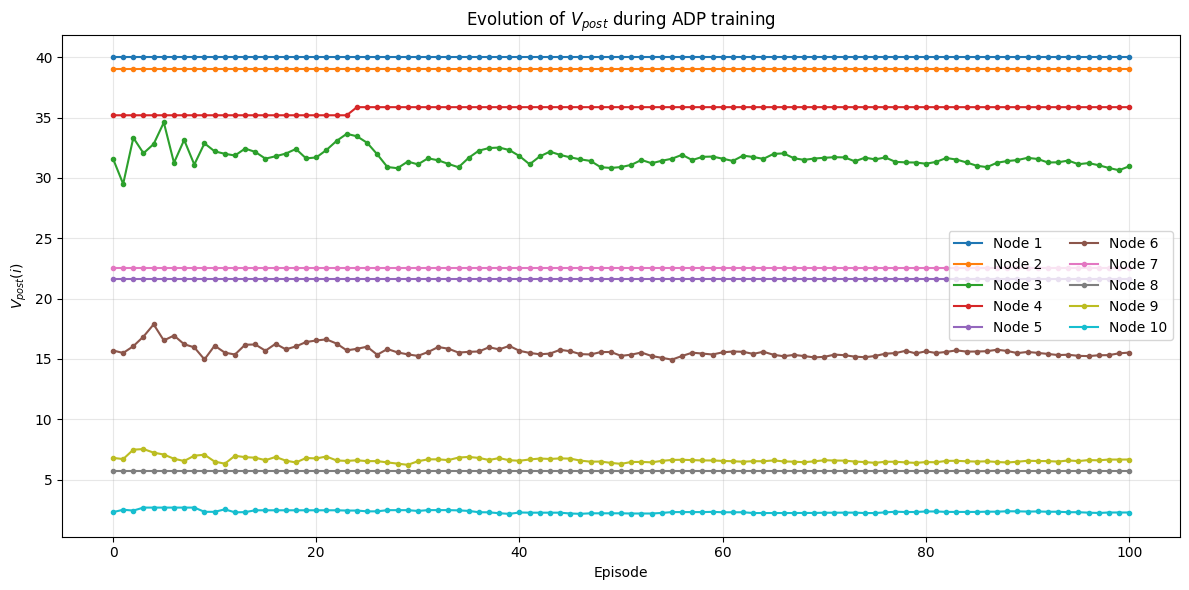

In [16]:
df_vpost = pd.DataFrame(V_post_history)
df_vpost.index.name = "episode"

plt.figure(figsize=(12, 6))

for node in df_vpost.columns:
    if node != destination_node:
        plt.plot(
            df_vpost.index,
            df_vpost[node],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=f"Node {node}"
        )

plt.xlabel("Episode")
plt.ylabel(r"$V_{post}(i)$")
plt.title(r"Evolution of $V_{post}$ during ADP training")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [17]:
number_of_training_runs = 1000
number_of_episodes_per_run = 100

average_costs_across_runs = []
histoy_V_post_across_runs = []


for run_id in range(number_of_training_runs):
    V_post = initialize_v_bar_post(network, destination_node)

    V_post, episode_costs, path_history, path_counts, V_post_history = train(
    network=network,
    origin_node=1,
    destination_node=11,
    V_post=V_post,
    theta_alpha=10,
    number_of_episodes=100
)
    average_cost = sum(episode_costs) / len(episode_costs)
    average_costs_across_runs.append(average_cost)
    histoy_V_post_across_runs.append(V_post_history)

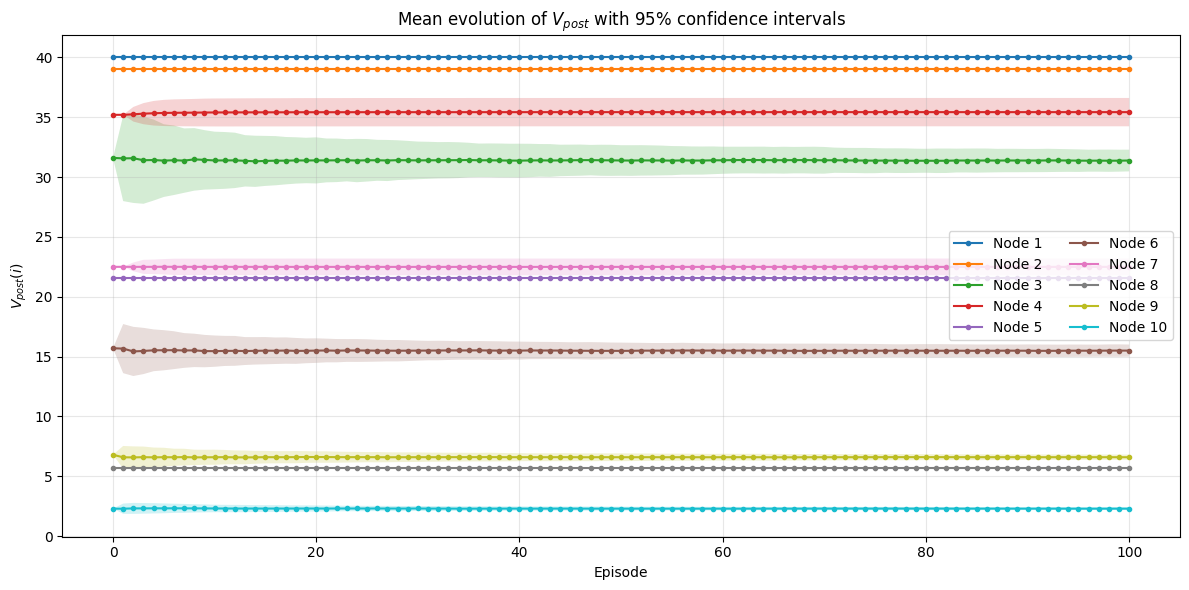

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PLOT MEAN V_post WITH 95% CONFIDENCE INTERVAL
# ============================================================

all_run_histories = [
    pd.DataFrame(V_post_history)
    for V_post_history in histoy_V_post_across_runs
]

nodes = sorted(all_run_histories[0].columns)
episodes = np.arange(len(all_run_histories[0]))

n_runs = len(all_run_histories)
z = 1.96

plt.figure(figsize=(12, 6))

for node in nodes:
    if node == destination_node:
        continue

    # matriz: linhas = runs, colunas = episódios
    values = np.array([
        df_run[node].to_numpy()
        for df_run in all_run_histories
    ])

    mean_vpost = values.mean(axis=0)
    std_vpost = values.std(axis=0, ddof=1)

    # intervalo de confiança de 95% da média
    margin_error = z * std_vpost #/ np.sqrt(n_runs)

    ci_lower = mean_vpost - margin_error
    ci_upper = mean_vpost + margin_error

    plt.plot(
        episodes,
        mean_vpost,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"Node {node}"
    )

    plt.fill_between(
        episodes,
        ci_lower,
        ci_upper,
        alpha=0.20
    )

plt.xlabel("Episode")
plt.ylabel(r"$V_{post}(i)$")
plt.title(r"Mean evolution of $V_{post}$ with 95% confidence intervals")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CHECK CI WIDTH
# ============================================================

for node in nodes:
    if node == destination_node:
        continue

    values = np.array([
        df_run[node].to_numpy()
        for df_run in all_run_histories
    ])

    std_vpost = values.std(axis=0, ddof=1)
    margin_error = 1.96 * std_vpost / np.sqrt(len(all_run_histories))
    ci_width = 2 * margin_error

    print(
        f"Node {node}: "
        f"max CI width = {ci_width.max():.6f}, "
        f"mean CI width = {ci_width.mean():.6f}"
    )

Node 1: max CI width = 0.000000, mean CI width = 0.000000
Node 2: max CI width = 0.000000, mean CI width = 0.000000
Node 3: max CI width = 0.236214, mean CI width = 0.093476
Node 4: max CI width = 0.074870, mean CI width = 0.072496
Node 5: max CI width = 0.000000, mean CI width = 0.000000
Node 6: max CI width = 0.129911, mean CI width = 0.050365
Node 7: max CI width = 0.044268, mean CI width = 0.042901
Node 8: max CI width = 0.000000, mean CI width = 0.000000
Node 9: max CI width = 0.059947, mean CI width = 0.023274
Node 10: max CI width = 0.029068, mean CI width = 0.012164


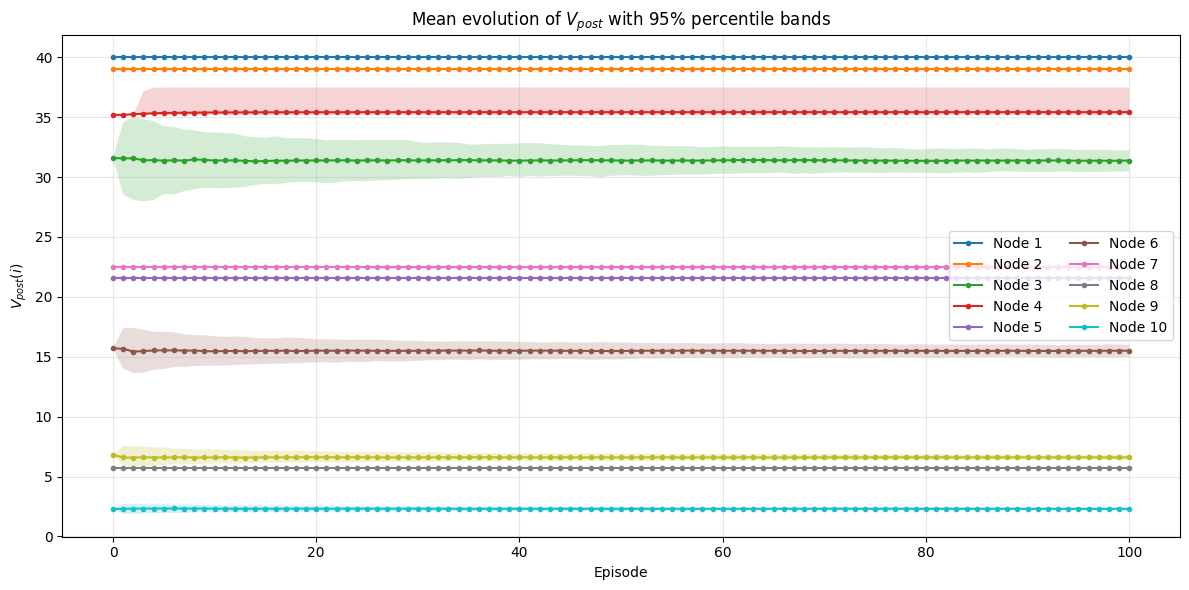

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PLOT MEAN V_post WITH 95% PERCENTILE BAND
# ============================================================

all_run_histories = [
    pd.DataFrame(V_post_history)
    for V_post_history in histoy_V_post_across_runs
]

nodes = sorted(all_run_histories[0].columns)
episodes = np.arange(len(all_run_histories[0]))

plt.figure(figsize=(12, 6))

for node in nodes:
    if node == destination_node:
        continue

    values = np.array([
        df_run[node].to_numpy()
        for df_run in all_run_histories
    ])

    mean_vpost = values.mean(axis=0)

    lower = np.percentile(values, 2.5, axis=0)
    upper = np.percentile(values, 97.5, axis=0)

    plt.plot(
        episodes,
        mean_vpost,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=f"Node {node}"
    )

    plt.fill_between(
        episodes,
        lower,
        upper,
        alpha=0.20
    )

plt.xlabel("Episode")
plt.ylabel(r"$V_{post}(i)$")
plt.title(r"Mean evolution of $V_{post}$ with 95% percentile bands")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [21]:
mean_of_average_costs = sum(average_costs_across_runs) / len(average_costs_across_runs)

print(f"Mean of average costs in 1000 runs: {mean_of_average_costs:.4f}")

Mean of average costs in 1000 runs: 39.7957


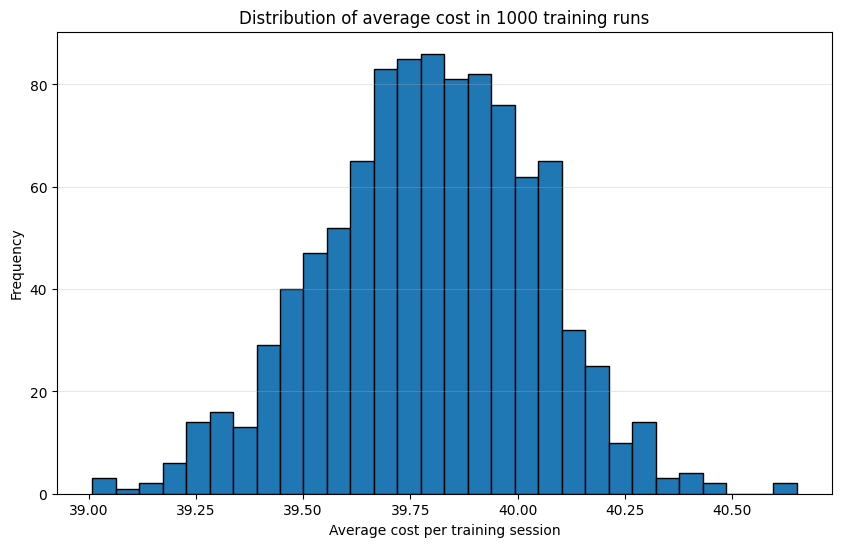

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(average_costs_across_runs, bins=30, edgecolor="black")
plt.xlabel("Average cost per training session")
plt.ylabel("Frequency")
plt.title("Distribution of average cost in 1000 training runs")
plt.grid(axis="y", alpha=0.3)
plt.show()